Plot study area map and Salish Sea Atlantis model polygons

In [1]:
import geopandas as gpd
import cartopy.crs as ccrs
import matplotlib.cm as cm
import warnings
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from shapely.affinity import rotate
from mpl_toolkits.axes_grid1 import make_axes_locatable
from cartopy import crs, feature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [2]:
warnings.simplefilter('ignore')

In [3]:
shapefile_name = "/ocean/rlovindeer/Atlantis/ssam_oceanparcels/SalishSea/SalishSea_July172019_2/SalishSea_July172019.shp"
data_df_original = gpd.read_file(shapefile_name)
data_df_original = data_df_original.sort_values(by=['BOX_ID'])
data_df = data_df_original.set_index('BOX_ID')
box_depth = data_df['BOTZ']
land_boxes = box_depth==0
land_boxes = data_df.index[land_boxes]

land_df = data_df.loc[land_boxes]

In [4]:
# Read shapefile
gdf = gpd.read_file(shapefile_name)
gdf = gdf.to_crs(epsg=4326)

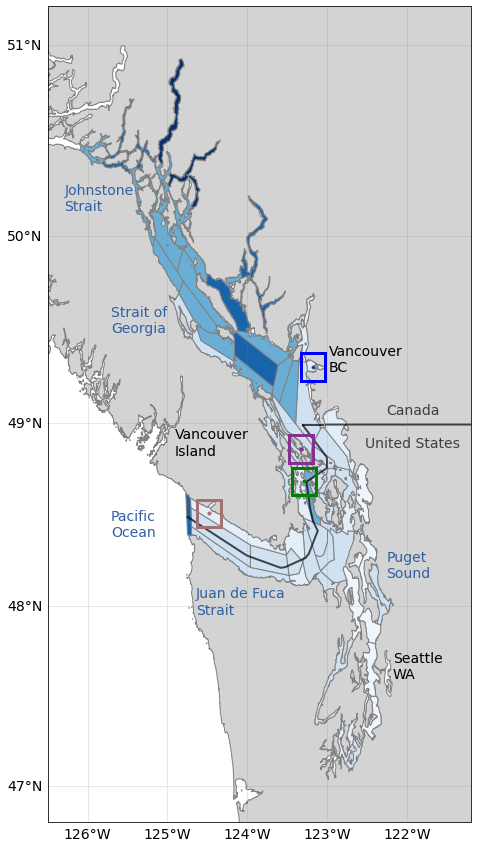

In [177]:
# Create Mercator map
fig = plt.figure(figsize=(12, 15))
#fig.add_subplot()
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent([-126.5, -121.2, 46.8, 51.2],crs=ccrs.PlateCarree())
# Plot shapefile
gdf.plot(column='BOTZ',
    ax=ax,cax=cax, cmap=cm.Blues, vmax=500,
    transform=ccrs.PlateCarree(), 
    facecolor='#EBEBEB',edgecolor='grey', 
    #legend=True, legend_kwds={'label': 'Box Depth (m)', "orientation": "horizontal"}, 
)

# Add text labels
ax.add_feature(feature.GSHHSFeature('full', edgecolor='grey', facecolor='lightgrey'))
ax.add_feature(feature.BORDERS,edgecolor='black',linewidth=2,alpha=0.7)
ax.text(0.15, 0.35, 'Pacific\nOcean', transform=ax.transAxes,color='#2F61A4')
ax.text(0.80, 0.30, 'Puget\nSound', transform=ax.transAxes,color='#2F61A4')
ax.text(0.35, 0.255, 'Juan de Fuca\nStrait', transform=ax.transAxes,color='#2F61A4')
ax.text(-122.331030+0.15, 47.603895, 'Seattle\nWA', transform=ccrs.PlateCarree(),color='k')  
ax.text(0.8, 0.5, 'Canada', transform=ax.transAxes,color='k',alpha=0.7)
ax.text(0.75, 0.46, 'United States', transform=ax.transAxes,color='k',alpha=0.7)
ax.text(0.15, 0.60, 'Strait of\nGeorgia', transform=ax.transAxes, color='#2F61A4') #,weight='bold'
ax.text(0.3, 0.45, 'Vancouver\nIsland', transform=ax.transAxes, color='k') #,weight='bold'
ax.text(-123.128392+0.15, 49.280076,'Vancouver\nBC', transform=ccrs.PlateCarree(), color='k') #,weight='bold'
ax.text(0.04, 0.75, 'Johnstone\nStrait', transform=ax.transAxes, color='#2F61A4')

#Spill coordinates
APlon, APlat = -123.3239, 48.8594
TPlon, TPlat = -123.293519444444, 48.6843916666667
EBlon, EBlat = -123.181433333333,49.3002972222222
JFlon, JFlat = -124.4823,48.5103

# Add box insets
width = 0.3
height = 0.15
line_width = 3

Active_Pass = Rectangle((APlon-width/2,APlat-height/2),width,height,facecolor='none',edgecolor='#863092',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
Turn_Point = Rectangle((TPlon-width/2,TPlat-height/2),width,height,facecolor='none',edgecolor='green',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
English_Bay = Rectangle((EBlon-width/2,EBlat-height/2),width,height,facecolor='none',edgecolor='blue',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
Jstrait = Rectangle((JFlon-width/2,JFlat-height/2),width,height,facecolor='none',edgecolor='#A27170',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)

ax.add_patch(Active_Pass)
ax.add_patch(Turn_Point)
ax.add_patch(English_Bay)
ax.add_patch(Jstrait)

# Add spill points
marker_size = 3


ax.plot(APlon, APlat, marker='o', markersize=marker_size, color='#863092', markeredgecolor='#863092', transform=ccrs.PlateCarree(), zorder=10)
ax.plot(TPlon, TPlat, marker='o', markersize=marker_size, color='green', markeredgecolor='green', transform=ccrs.PlateCarree(), zorder=10) ##6DB48E
ax.plot(EBlon, EBlat, marker='o', markersize=marker_size, color='blue', markeredgecolor='#2F61A4', transform=ccrs.PlateCarree(), zorder=10)
ax.plot(JFlon, JFlat, marker='o', markersize=marker_size, color='#A27170', markeredgecolor='#A27170', transform=ccrs.PlateCarree(), zorder=10)

#fig.add_subplot()

gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.5,color='gray', alpha=0.5,linestyle='--')

# Only label left and bottom axes
gl.top_labels = False
gl.right_labels = False

# Format as longitude/latitude
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
plt.show()

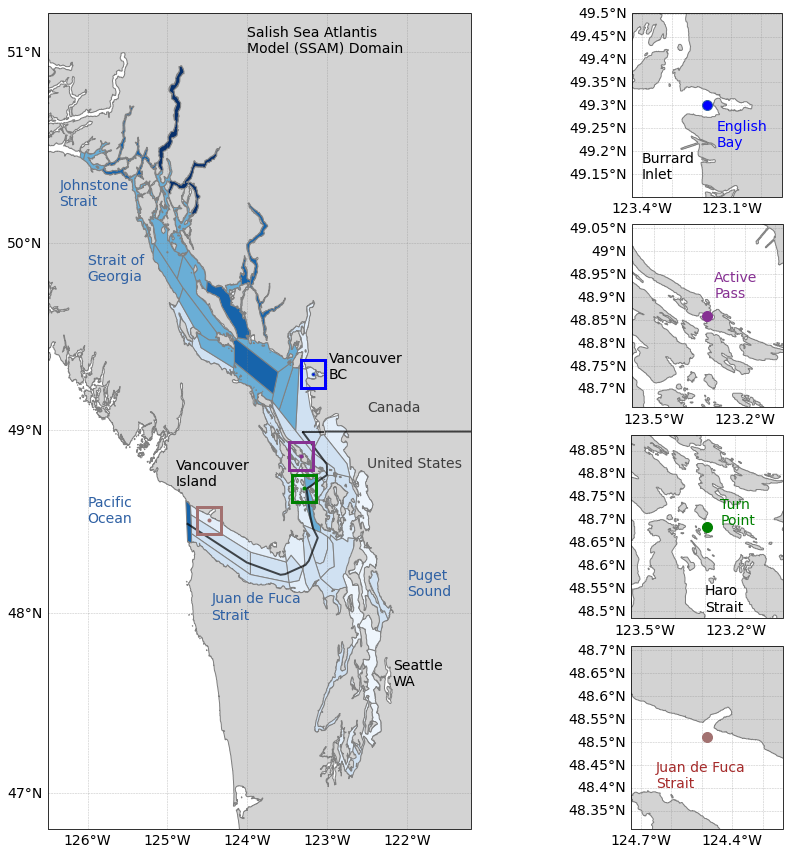

In [238]:
proj = ccrs.Mercator()

fig = plt.figure(figsize=(15, 15), constrained_layout=True )

# 4 rows, 5 columns
gs = plt.GridSpec(nrows=4,ncols=2,width_ratios=[1.5, 1], height_ratios=[1,1,1,1],
    wspace=0.15, hspace=0.15)

# Make sure the GeoDataFrame is in WGS84 (or convert it)
gdf = gdf.to_crs(epsg=4326)

# Create Mercator map
ax_main = fig.add_subplot(gs[:, 0], projection=proj)
# Four small maps in the last column
ax1 = fig.add_subplot(gs[0, 1], projection=proj)
ax2 = fig.add_subplot(gs[1, 1], projection=proj)
ax3 = fig.add_subplot(gs[2, 1], projection=proj)
ax4 = fig.add_subplot(gs[3, 1], projection=proj)

#ax = plt.axes(projection=ccrs.Mercator())

ax_main.set_extent([-126.5, -121.2, 46.8, 51.2],crs=ccrs.PlateCarree())
# Plot shapefile
gdf.plot(column='BOTZ',
    ax=ax_main, cmap=cm.Blues, vmax=500,
    transform=ccrs.PlateCarree(), 
    facecolor='#EBEBEB',edgecolor='grey', 
    #legend=True, legend_kwds={'label': 'Box Depth (m)', "orientation": "horizontal"}, 
)

# Add text labels
cwater = '#2F61A4' ##88CCEE

ax_main.add_feature(feature.GSHHSFeature('full', edgecolor='grey', facecolor='lightgrey'))
ax_main.add_feature(feature.BORDERS,edgecolor='black',linewidth=2,alpha=0.7)
ax_main.text(-124, 51, 'Salish Sea Atlantis\nModel (SSAM) Domain', transform=ccrs.PlateCarree(),color='k')
ax_main.text(-126, 48.5, 'Pacific\nOcean', transform=ccrs.PlateCarree(),color=cwater)
ax_main.text(-122, 48.1, 'Puget\nSound', transform=ccrs.PlateCarree(),color=cwater)
ax_main.text(-124.45, 47.97, 'Juan de Fuca\nStrait', transform=ccrs.PlateCarree(),color=cwater)
ax_main.text(-122.331030+0.15, 47.603895, 'Seattle\nWA', transform=ccrs.PlateCarree(),color='k')  
ax_main.text(-122.5, 49.1, 'Canada', transform=ccrs.PlateCarree(),color='k',alpha=0.7)
ax_main.text(-122.5, 48.8, 'United States', transform=ccrs.PlateCarree(),color='k',alpha=0.7)
ax_main.text(-126, 49.8, 'Strait of\nGeorgia', transform=ccrs.PlateCarree(), color=cwater) #,weight='bold'
ax_main.text(-124.9, 48.7, 'Vancouver\nIsland', transform=ccrs.PlateCarree(), color='k') #,weight='bold'
ax_main.text(-123.128392+0.15, 49.280076,'Vancouver\nBC', transform=ccrs.PlateCarree(), color='k') #,weight='bold'
ax_main.text(-126.35, 50.2, 'Johnstone\nStrait', transform=ccrs.PlateCarree(), color=cwater) 

#Spill coordinates
APlon, APlat = -123.3239, 48.8594
TPlon, TPlat = -123.293519444444, 48.6843916666667
EBlon, EBlat = -123.181433333333,49.3002972222222
JFlon, JFlat = -124.4823,48.5103

# Add box insets
width = 0.3
height = 0.15
line_width = 3

Active_Pass = Rectangle((APlon-width/2,APlat-height/2),width,height,facecolor='none',edgecolor='#863092',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
Turn_Point = Rectangle((TPlon-width/2,TPlat-height/2),width,height,facecolor='none',edgecolor='green',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
English_Bay = Rectangle((EBlon-width/2,EBlat-height/2),width,height,facecolor='none',edgecolor='blue',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
Jstrait = Rectangle((JFlon-width/2,JFlat-height/2),width,height,facecolor='none',edgecolor='#A27170',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)

ax_main.add_patch(Active_Pass)
ax_main.add_patch(Turn_Point)
ax_main.add_patch(English_Bay)
ax_main.add_patch(Jstrait)

# Add spill points
marker_size = 3

ax_main.plot(APlon, APlat, marker='o', markersize=marker_size, color='#863092', markeredgecolor='#863092', transform=ccrs.PlateCarree(), zorder=10)
ax_main.plot(TPlon, TPlat, marker='o', markersize=marker_size, color='green', markeredgecolor='green', transform=ccrs.PlateCarree(), zorder=10) ##6DB48E
ax_main.plot(EBlon, EBlat, marker='o', markersize=marker_size, color='blue', markeredgecolor='#2F61A4', transform=ccrs.PlateCarree(), zorder=10)
ax_main.plot(JFlon, JFlat, marker='o', markersize=marker_size, color='#A27170', markeredgecolor='#A27170', transform=ccrs.PlateCarree(), zorder=10)

#side plots
width = 0.5
height = 0.4
marker_size = 10
ax1.set_extent([EBlon-width/2, EBlon+width/2, EBlat-height/2, EBlat+height/2],crs=ccrs.PlateCarree())
ax1.plot(EBlon, EBlat, marker='o', markersize=marker_size, color='blue', markeredgecolor='#2F61A4', transform=ccrs.PlateCarree(), zorder=10)
ax1.text(-123.4, 49.14,'Burrard\nInlet', transform=ccrs.PlateCarree(), color='k')
ax1.text(-123.15, 49.21,'English\nBay', transform=ccrs.PlateCarree(), color='blue')

ax2.set_extent([APlon-width/2, APlon+width/2, APlat-height/2, APlat+height/2],crs=ccrs.PlateCarree())
ax2.plot(APlon, APlat, marker='o', markersize=marker_size, color='#863092', markeredgecolor='#863092', transform=ccrs.PlateCarree(), zorder=10)
ax2.text(-123.3, 48.9,'Active\nPass', transform=ccrs.PlateCarree(), color='#863092')
ax2.annotate('Active\nPass',xy=(APlon, APlat),xytext=(APlon+1, APlat), fontsize=14,
    arrowprops=dict(facecolor='#863092'),verticalalignment='top',horizontalalignment='center')

ax3.set_extent([TPlon-width/2, TPlon+width/2, TPlat-height/2, TPlat+height/2],crs=ccrs.PlateCarree())
ax3.plot(TPlon, TPlat, marker='o', markersize=marker_size, color='green', markeredgecolor='green', transform=ccrs.PlateCarree(), zorder=10) ##6DB48E
ax3.text(-123.25, 48.69,'Turn\nPoint', transform=ccrs.PlateCarree(), color='green')
ax3.text(-123.3, 48.5,'Haro\nStrait', transform=ccrs.PlateCarree(), color='k')

ax4.set_extent([JFlon-width/2, JFlon+width/2, JFlat-height/2, JFlat+height/2],crs=ccrs.PlateCarree())
ax4.plot(JFlon, JFlat, marker='o', markersize=marker_size, color='#A27170', markeredgecolor='#A27170', transform=ccrs.PlateCarree(), zorder=10)
ax4.text(-124.65, 48.4,'Juan de Fuca\nStrait', transform=ccrs.PlateCarree(), color='brown') ##A27170

for ax in [ax_main, ax1, ax2, ax3, ax4]:
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.5,color='gray', alpha=0.5,linestyle='--')
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = False
    gl.right_labels = False    

for ax in [ax1, ax2, ax3, ax4]:
    ax.add_feature(feature.GSHHSFeature('full', edgecolor='grey', facecolor='lightgrey'))
    #ax.coastlines(resolution='10m')
    
plt.show()

In [7]:
plt.rcParams['font.size'] = 12

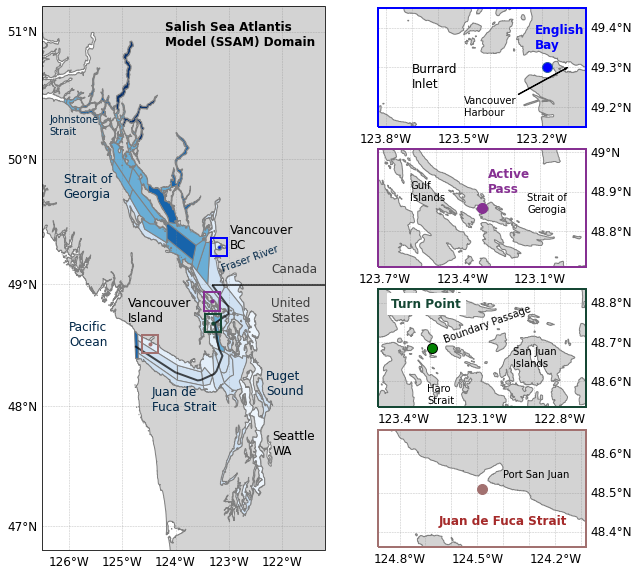

In [93]:
proj = ccrs.Mercator()

fig = plt.figure(figsize=(10, 10), constrained_layout=True )

# 4 rows, 5 columns
gs = plt.GridSpec(nrows=4,ncols=2,width_ratios=[1.5, 1], height_ratios=[1,1,1,1],
    wspace=0.15, hspace=0.15)

# Make sure the GeoDataFrame is in WGS84 (or convert it)
gdf = gdf.to_crs(epsg=4326)

# Create Mercator map
ax_main = fig.add_subplot(gs[:, 0], projection=proj)
# Four small maps in the last column
ax1 = fig.add_subplot(gs[0, 1], projection=proj)
ax2 = fig.add_subplot(gs[1, 1], projection=proj)
ax3 = fig.add_subplot(gs[2, 1], projection=proj)
ax4 = fig.add_subplot(gs[3, 1], projection=proj)

#ax = plt.axes(projection=ccrs.Mercator())

ax_main.set_extent([-126.5, -121.2, 46.8, 51.2],crs=ccrs.PlateCarree())
# Plot shapefile
gdf.plot(column='BOTZ',
    ax=ax_main, cmap=cm.Blues, vmax=500,
    transform=ccrs.PlateCarree(), 
    facecolor='#EBEBEB',edgecolor='grey', 
    #legend=True, legend_kwds={'label': 'Box Depth (m)', "orientation": "horizontal"}, 
)

# Add text labels
cwater = '#002647'#004481' #2F61A4 ##88CCEE

ax_main.add_feature(feature.GSHHSFeature('full', edgecolor='grey', facecolor='lightgrey'))
ax_main.add_feature(feature.BORDERS,edgecolor='black',linewidth=2,alpha=0.7)
ax_main.text(-124.2, 50.9, 'Salish Sea Atlantis\nModel (SSAM) Domain', transform=ccrs.PlateCarree(),color='k',weight='bold')
ax_main.text(-126, 48.5, 'Pacific\nOcean', transform=ccrs.PlateCarree(),color=cwater)
ax_main.text(-122.3, 48.1, 'Puget\nSound', transform=ccrs.PlateCarree(),color=cwater)
ax_main.text(-124.45, 47.97, 'Juan de\nFuca Strait', transform=ccrs.PlateCarree(),color=cwater)
ax_main.text(-122.331030+0.15, 47.603895, 'Seattle\nWA', transform=ccrs.PlateCarree(),color='k')  
ax_main.text(-122.2, 49.1, 'Canada', transform=ccrs.PlateCarree(),color='k',alpha=0.7)
ax_main.text(-122.2, 48.7, 'United\nStates', transform=ccrs.PlateCarree(),color='k',alpha=0.7)
ax_main.text(-126.1, 49.7, 'Strait of\nGeorgia', transform=ccrs.PlateCarree(), color=cwater)
ax_main.text(-124.9, 48.7, 'Vancouver\nIsland', transform=ccrs.PlateCarree(), color='k') 
ax_main.text(-123.128392+0.15, 49.280076+0.01,'Vancouver\nBC', transform=ccrs.PlateCarree(), color='k')
ax_main.text(-126.36, 50.2, 'Johnstone\nStrait', transform=ccrs.PlateCarree(), color=cwater,size=10) 
ax_main.text(-123.156982,49.110233, 'Fraser River',transform=ccrs.PlateCarree(),color=cwater,size=10,rotation=20)

#Spill coordinates
APlon, APlat = -123.3239, 48.8594
TPlon, TPlat = -123.293519444444, 48.6843916666667
EBlon, EBlat = -123.181433333333,49.3002972222222
JFlon, JFlat = -124.4823,48.5103

# Add box insets
width = 0.3
height = 0.15
line_width = 2

Active_Pass = Rectangle((APlon-width/2,APlat-height/2),width,height,facecolor='none',edgecolor='#863092',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
Turn_Point = Rectangle((TPlon-width/2,TPlat-height/2),width,height,facecolor='none',edgecolor='#154734',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
English_Bay = Rectangle((EBlon-width/2,EBlat-height/2),width,height,facecolor='none',edgecolor='blue',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
Jstrait = Rectangle((JFlon-width/2,JFlat-height/2),width,height,facecolor='none',edgecolor='#A27170',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)

ax_main.add_patch(Active_Pass)
ax_main.add_patch(Turn_Point)
ax_main.add_patch(English_Bay)
ax_main.add_patch(Jstrait)

# Add spill points
marker_size = 3

ax_main.plot(APlon, APlat, marker='o', markersize=marker_size, color='#863092', markeredgecolor='#863092', transform=ccrs.PlateCarree(), zorder=10)
ax_main.plot(TPlon, TPlat, marker='o', markersize=marker_size, color='#154734', markeredgecolor='#154734', transform=ccrs.PlateCarree(), zorder=10) ##6DB48E
ax_main.plot(EBlon, EBlat, marker='o', markersize=marker_size, color='blue', markeredgecolor='#2F61A4', transform=ccrs.PlateCarree(), zorder=10)
ax_main.plot(JFlon, JFlat, marker='o', markersize=marker_size, color='#A27170', markeredgecolor='#A27170', transform=ccrs.PlateCarree(), zorder=10)

#side plots
width = 0.8
height = 0.3
marker_size = 10
EB_end_grid = -123.03
ax1.set_extent([EB_end_grid-width, EB_end_grid, EBlat-height/2, EBlat+height/2],crs=ccrs.PlateCarree())
ax1.plot(EBlon, EBlat, marker='o', markersize=marker_size, color='blue', markeredgecolor='#2F61A4', transform=ccrs.PlateCarree(), zorder=10)
ax1.text(-123.7, 49.25,'Burrard\nInlet', transform=ccrs.PlateCarree(), color='k')
ax1.text(-123.225, 49.35,'English\nBay', transform=ccrs.PlateCarree(), color='blue',weight='bold')
ax1.annotate('Vancouver\nHarbour',
            xy=(-123.1, 49.3), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax1),
            xytext=(-123.5,49.18), textcoords=ccrs.PlateCarree()._as_mpl_transform(ax1), fontsize=10,
            arrowprops=dict(headwidth=2, headlength=3, width=0.5, facecolor='k'))

ax2.set_extent([APlon-width/2, APlon+width/2, APlat-height/2, APlat+height/2],crs=ccrs.PlateCarree())
ax2.plot(APlon, APlat, marker='o', markersize=marker_size, color='#863092', markeredgecolor='#863092', transform=ccrs.PlateCarree(), zorder=10)
ax2.text(-123.3, 48.9,'Active\nPass', transform=ccrs.PlateCarree(), color='#863092',weight='bold')
ax2.text(-123.15, 48.85,'Strait of\nGerogia', transform=ccrs.PlateCarree(), color='k',size=10)
ax2.text(-123.6, 48.88,'Gulf\nIslands', transform=ccrs.PlateCarree(), color='k',size=10)

TP_end_grid = -123.5
ax3.set_extent([TP_end_grid, TP_end_grid+width, TPlat-height/2, TPlat+height/2],crs=ccrs.PlateCarree())
ax3.plot(TPlon, TPlat, marker='o', markersize=marker_size, color='green', markeredgecolor='k', transform=ccrs.PlateCarree(), zorder=10) ##6DB48E
ax3.text(-123.45, 48.79,'Turn Point', transform=ccrs.PlateCarree(), color='#154734',weight='bold',backgroundcolor='white')
ax3.text(-123.3109, 48.545644,'Haro\nStrait', transform=ccrs.PlateCarree(), color='k',size=10)
ax3.text(-123.25, 48.7,'Boundary Passage', transform=ccrs.PlateCarree(), color='k',size=10,rotation=20)
ax3.text(-122.98, 48.64,'San Juan\nIslands', transform=ccrs.PlateCarree(), color='k',size=10)

ax4.set_extent([JFlon-width/2, JFlon+width/2, JFlat-height/2, JFlat+height/2],crs=ccrs.PlateCarree())
ax4.plot(JFlon, JFlat, marker='o', markersize=marker_size, color='#A27170', markeredgecolor='#A27170', transform=ccrs.PlateCarree(), zorder=10)
ax4.text(-124.65, 48.42,'Juan de Fuca Strait', transform=ccrs.PlateCarree(), color='brown',weight='bold') ##A27170
ax4.text(-124.4, 48.54,'Port San Juan', transform=ccrs.PlateCarree(), color='k',size=10) ##A27170

for ax in [ax_main]:
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.5,color='gray', alpha=0.5,linestyle='--')
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = False
    gl.right_labels = False    

for ax in [ax1, ax2, ax3, ax4]:
    gl = ax.gridlines(crs=ccrs.PlateCarree(),x_inline=False, y_inline=False,draw_labels=True,linewidth=0.5,color='gray', alpha=0.5,linestyle='--')
    ax.add_feature(feature.GSHHSFeature('full', edgecolor='grey', facecolor='lightgrey'))
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.ylocator = mticker.FixedLocator([48.4,48.5,48.6,48.7,48.8,48.9,49.0,49.1,49.2,49.3,49.4])
    gl.top_labels = False
    gl.left_labels = False   
    #ax.coastlines(resolution='10m')

for ax, colour in zip([ax1, ax2, ax3, ax4],['blue','#863092','#154734','#A27170']):
    plt.setp(ax.spines.values(), color=colour, linewidth=2)
plt.show()

In [94]:
fig.savefig('Figures/Fig1-Map.png',bbox_inches='tight',dpi=300)